# Lab 03：板块周期轮动研究

## tl;dr

2010-01至2026-06的198个完整月份显示，板块轮动现象很强：月度冠军在197次
月间转换中有89.34%发生变化，相邻月Top 3的Jaccard中位数仅0.20，月度最佳与
最差行业收益平均相差14.62个百分点。

但短期领先的预测力很弱。1、3、6个月动量的平均Rank IC只有0.019、0.033和
0.040；12个月动量相对较强，平均Rank IC为0.071，朴素t值2.28，过去12个月
Top 3在下月平均领先其余行业0.88个百分点。

预先指定的“12个月动量Top 3、单边成本20 bp”在2011-01至2026-06实现10.41%
CAGR，高于十大行业等权的3.92%和沪深300的3.04%，但最大回撤为-46.66%，深于
两个基准。它在2015—2019年落后行业等权，超额收益主要在2020年以来扩大，因此
结论是“存在中长期、阶段敏感的轮动证据”，不是稳定可预测的轮动定律。


## Context & Methods

### 研究问题

2010年以来，沪深300十大行业是否存在可识别、可延续、在扣除换手成本后仍可利用的
周期轮动？

### 板块与时间

使用中证行业分类下的沪深300十大行业指数：能源、原材料、工业、可选消费、
主要消费、医药卫生、金融地产、信息技术、通信服务、公用事业。

- 日数据截止：2026-07-29；
- 月度研究：2010-01 至 2026-06，仅完整月份；
- 策略统一评估：2011-01 至 2026-06；
- 主源：腾讯财经指数日线；校验源：新浪财经指数日线；
- 所有指数均为价格指数，不含股息再投资。

### Key Assumptions

1. 月末收盘形成信号，下一月持有，信号至少滞后一个月；
2. 行业指数可作为板块价格代理，但历史上并非每个板块都有低成本可交易ETF；
3. 单边换手成本基准为20 bp，并测试0、10、20、50 bp；
4. 无风险利率按0计算 Sharpe，仅用于策略间同口径比较；
5. 本实验研究价格周期，不声称识别宏观经济周期或因果关系。


In [1]:
import contextlib
import io
import json
import math
from pathlib import Path

import akshare as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from IPython.display import display

plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

WORKING_DIR = Path.cwd().resolve()
LAB_DIR = next(
    (
        path
        for path in [WORKING_DIR, *WORKING_DIR.parents]
        if path.name == "03_板块周期轮动研究"
    ),
    None,
)
if LAB_DIR is None:
    candidate = WORKING_DIR / "labs" / "03_板块周期轮动研究"
    if candidate.is_dir():
        LAB_DIR = candidate
if LAB_DIR is None:
    raise FileNotFoundError("请从仓库根目录或 Lab 03 目录运行")

DATA_DIR = LAB_DIR / "data"
CHART_DIR = DATA_DIR / "charts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

DAILY_START = pd.Timestamp("2009-12-01")
DAILY_END = pd.Timestamp("2026-07-29")
MONTHLY_START = pd.Period("2010-01", freq="M")
MONTHLY_END = pd.Period("2026-06", freq="M")
EVALUATION_START = pd.Period("2011-01", freq="M")
REFRESH_DATA = False

SECTOR_SPECS = {
    "000908": "能源",
    "000909": "原材料",
    "000910": "工业",
    "000911": "可选消费",
    "000912": "主要消费",
    "000913": "医药卫生",
    "000914": "金融地产",
    "000915": "信息技术",
    "000916": "通信服务",
    "000917": "公用事业",
}
BENCHMARK_CODE = "000300"
BENCHMARK_NAME = "沪深300"
SERIES_SPECS = {**SECTOR_SPECS, BENCHMARK_CODE: BENCHMARK_NAME}
SECTOR_NAMES = list(SECTOR_SPECS.values())

print("AKShare:", ak.__version__)
print("日数据截止:", DAILY_END.date())
print("完整月度区间:", MONTHLY_START, "至", MONTHLY_END)


AKShare: 1.18.78
日数据截止: 2026-07-29
完整月度区间: 2010-01 至 2026-06


## Data

### 1. 获取主源与校验源

腾讯序列作为主数据。新浪序列只在共同日期检查收盘价，不用来拼接腾讯缺口。
缓存文件存在时默认复用，删除 `data/` 或把 `REFRESH_DATA=True` 可强制刷新。


In [2]:
PRIMARY_PATH = DATA_DIR / "index_daily_tencent.parquet"
BACKUP_PATH = DATA_DIR / "index_daily_sina.parquet"


def normalize_history(
    frame: pd.DataFrame, code_value: str, name_value: str, source: str
) -> pd.DataFrame:
    normalized = frame[["date", "close"]].copy()
    normalized["date"] = pd.to_datetime(normalized["date"])
    normalized["close"] = pd.to_numeric(normalized["close"], errors="coerce")
    normalized["series_code"] = code_value
    normalized["series_name"] = name_value
    normalized["series_type"] = (
        "benchmark" if code_value == BENCHMARK_CODE else "sector"
    )
    normalized["source"] = source
    return normalized[
        [
            "date", "series_code", "series_name", "series_type",
            "close", "source",
        ]
    ]


def fetch_tencent() -> pd.DataFrame:
    frames = []
    errors = []
    for code_value, name_value in SERIES_SPECS.items():
        try:
            with contextlib.redirect_stderr(io.StringIO()):
                raw = ak.stock_zh_index_daily_tx(
                    symbol=f"sh{code_value}"
                )
            frames.append(
                normalize_history(
                    raw, code_value, name_value, "腾讯财经"
                )
            )
        except Exception as exc:
            errors.append(
                {"series_code": code_value, "error": repr(exc)}
            )
    if errors:
        display(pd.DataFrame(errors))
        raise RuntimeError("腾讯主源存在获取失败")
    return pd.concat(frames, ignore_index=True)


def fetch_sina() -> pd.DataFrame:
    frames = []
    errors = []
    for code_value, name_value in SERIES_SPECS.items():
        try:
            raw = ak.stock_zh_index_daily(symbol=f"sh{code_value}")
            frames.append(
                normalize_history(
                    raw, code_value, name_value, "新浪财经"
                )
            )
        except Exception as exc:
            errors.append(
                {"series_code": code_value, "error": repr(exc)}
            )
    if errors:
        display(pd.DataFrame(errors))
        raise RuntimeError("新浪校验源存在获取失败")
    return pd.concat(frames, ignore_index=True)


if REFRESH_DATA or not PRIMARY_PATH.is_file():
    primary_daily = fetch_tencent()
    primary_daily.to_parquet(PRIMARY_PATH, index=False)
else:
    primary_daily = pd.read_parquet(PRIMARY_PATH)

if REFRESH_DATA or not BACKUP_PATH.is_file():
    backup_daily = fetch_sina()
    backup_daily.to_parquet(BACKUP_PATH, index=False)
else:
    backup_daily = pd.read_parquet(BACKUP_PATH)

primary_daily["date"] = pd.to_datetime(primary_daily["date"])
backup_daily["date"] = pd.to_datetime(backup_daily["date"])
primary_daily = primary_daily.loc[
    primary_daily["date"].between(DAILY_START, DAILY_END)
].copy()
backup_daily = backup_daily.loc[
    backup_daily["date"].between(DAILY_START, DAILY_END)
].copy()

print("腾讯主源记录:", len(primary_daily))
print("新浪校验源记录:", len(backup_daily))


腾讯主源记录:

 44506
新浪校验源记录: 28696


### 2. 数据质量门禁

检查覆盖、唯一键、非正价格、共同日期差异和完整月度覆盖。当前盘中日及2026年7月
不完整月份均不进入月度研究。


In [3]:
primary_quality = (
    primary_daily.groupby(
        ["series_code", "series_name", "series_type"], as_index=False
    )
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        row_count=("date", "size"),
        duplicate_dates=("date", lambda values: int(values.duplicated().sum())),
        missing_close=("close", lambda values: int(values.isna().sum())),
        non_positive_close=("close", lambda values: int((values <= 0).sum())),
    )
)

source_comparison = primary_daily.merge(
    backup_daily[["date", "series_code", "close"]].rename(
        columns={"close": "close_sina"}
    ),
    on=["date", "series_code"],
    how="inner",
    validate="one_to_one",
)
source_comparison["relative_diff"] = (
    source_comparison["close"] - source_comparison["close_sina"]
).abs() / source_comparison["close"]
source_quality = (
    source_comparison.groupby(
        ["series_code", "series_name"], as_index=False
    )
    .agg(
        common_rows=("date", "size"),
        overlap_start=("date", "min"),
        overlap_end=("date", "max"),
        median_relative_diff=("relative_diff", "median"),
        max_relative_diff=("relative_diff", "max"),
    )
)
quality = primary_quality.merge(
    source_quality,
    on=["series_code", "series_name"],
    how="left",
    validate="one_to_one",
)
quality.to_csv(
    DATA_DIR / "data_quality.csv", index=False, encoding="utf-8-sig"
)
display(quality)

assert len(primary_quality) == 11
assert primary_quality["start_date"].le(pd.Timestamp("2010-01-04")).all()
assert primary_quality["end_date"].eq(DAILY_END).all()
assert primary_quality["duplicate_dates"].eq(0).all()
assert primary_quality["missing_close"].eq(0).all()
assert primary_quality["non_positive_close"].eq(0).all()
assert source_quality["common_rows"].ge(1_000).all()
assert source_quality["max_relative_diff"].lt(0.001).all()
print("日行情覆盖、唯一键、价格范围和双源差异门禁通过")


,series_code,series_name,series_type,start_date,end_date,row_count,duplicate_dates,missing_close,non_positive_close,common_rows,overlap_start,overlap_end,median_relative_diff,max_relative_diff
0,000300,沪深300,benchmark,2009-12-01,2026-07-29,4046,0,0,0,4046,2009-12-01,2026-07-29,7.225533e-07,0.000002
1,000908,能源,sector,2009-12-01,2026-07-29,4046,0,0,0,2231,2009-12-01,2019-01-30,1.081180e-06,0.000003
2,000909,原材料,sector,2009-12-01,2026-07-29,4046,0,0,0,2231,2009-12-01,2019-01-30,1.051431e-06,0.000004
3,000910,工业,sector,2009-12-01,2026-07-29,4046,0,0,0,2231,2009-12-01,2019-01-30,1.073226e-06,0.000003
4,000911,可选消费,sector,2009-12-01,2026-07-29,4046,0,0,0,2231,2009-12-01,2019-01-30,5.945604e-07,0.000002
5,000912,主要消费,sector,2009-12-01,2026-07-29,4046,0,0,0,2231,2009-12-01,2019-01-30,3.322049e-07,0.000001
6,000913,医药卫生,sector,2009-12-01,2026-07-29,4046,0,0,0,4046,2009-12-01,2026-07-29,2.897182e-07,0.000001
7,000914,金融地产,sector,2009-12-01,2026-07-29,4046,0,0,0,4046,2009-12-01,2026-07-29,4.787507e-07,0.000002
8,000915,信息技术,sector,2009-12-01,2026-07-29,4046,0,0,0,1586,2009-12-01,2016-06-13,1.473227e-06,0.000005
9,000916,通信服务,sector,2009-12-01,2026-07-29,4046,0,0,0,1586,2009-12-01,2016-06-13,1.121761e-06,0.000004


日行情覆盖、唯一键、价格范围和双源差异门禁通过


In [4]:
# 以每个自然月最后一个实际交易日收盘构造月末价格。
primary_daily["month"] = primary_daily["date"].dt.to_period("M")
monthly_long = (
    primary_daily.sort_values(["series_name", "date"])
    .groupby(["series_code", "series_name", "month"], as_index=False)
    .tail(1)
    .rename(columns={"date": "month_end_trade_date"})
)
monthly_close = monthly_long.pivot(
    index="month", columns="series_name", values="close"
).sort_index()
monthly_close = monthly_close.loc[
    pd.Period("2009-12", freq="M") : MONTHLY_END
]
monthly_returns = monthly_close.pct_change(fill_method=None).loc[
    MONTHLY_START:MONTHLY_END
]

month_end_dates = monthly_long.pivot(
    index="month", columns="series_name", values="month_end_trade_date"
).sort_index().loc[MONTHLY_START:MONTHLY_END]

assert monthly_returns.index.min() == MONTHLY_START
assert monthly_returns.index.max() == MONTHLY_END
assert len(monthly_returns) == 198
assert monthly_returns[SECTOR_NAMES + [BENCHMARK_NAME]].notna().all().all()
assert month_end_dates.notna().all().all()

monthly_long.to_parquet(
    DATA_DIR / "index_month_end.parquet", index=False
)
monthly_returns.reset_index().to_csv(
    DATA_DIR / "monthly_returns.csv", index=False, encoding="utf-8-sig"
)
print("完整月收益月份:", len(monthly_returns))
print("月度范围:", monthly_returns.index.min(), "至", monthly_returns.index.max())


完整月收益月份: 198
月度范围: 2010-01 至 2026-06


## Results

### 1. 年度板块表现与轮动空间

年度热力图用于观察差异和冠军更替，不作为可预测性证据。2026列仅包含上半年。


,winner,winner_return,loser,loser_return,top_bottom_spread
2010,医药卫生,0.219075,金融地产,-0.272628,0.491702
2011,主要消费,-0.098639,信息技术,-0.392705,0.294065
2012,金融地产,0.218426,通信服务,-0.323104,0.541529
2013,信息技术,0.394040,能源,-0.334357,0.728397
2014,金融地产,0.863365,信息技术,0.034734,0.828631
2015,信息技术,0.481094,能源,-0.188397,0.669492
2016,主要消费,0.083981,信息技术,-0.204092,0.288073
2017,主要消费,0.810190,工业,0.048603,0.761588
2018,公用事业,-0.071821,通信服务,-0.383053,0.311232
2019,主要消费,0.793192,公用事业,0.018557,0.774636


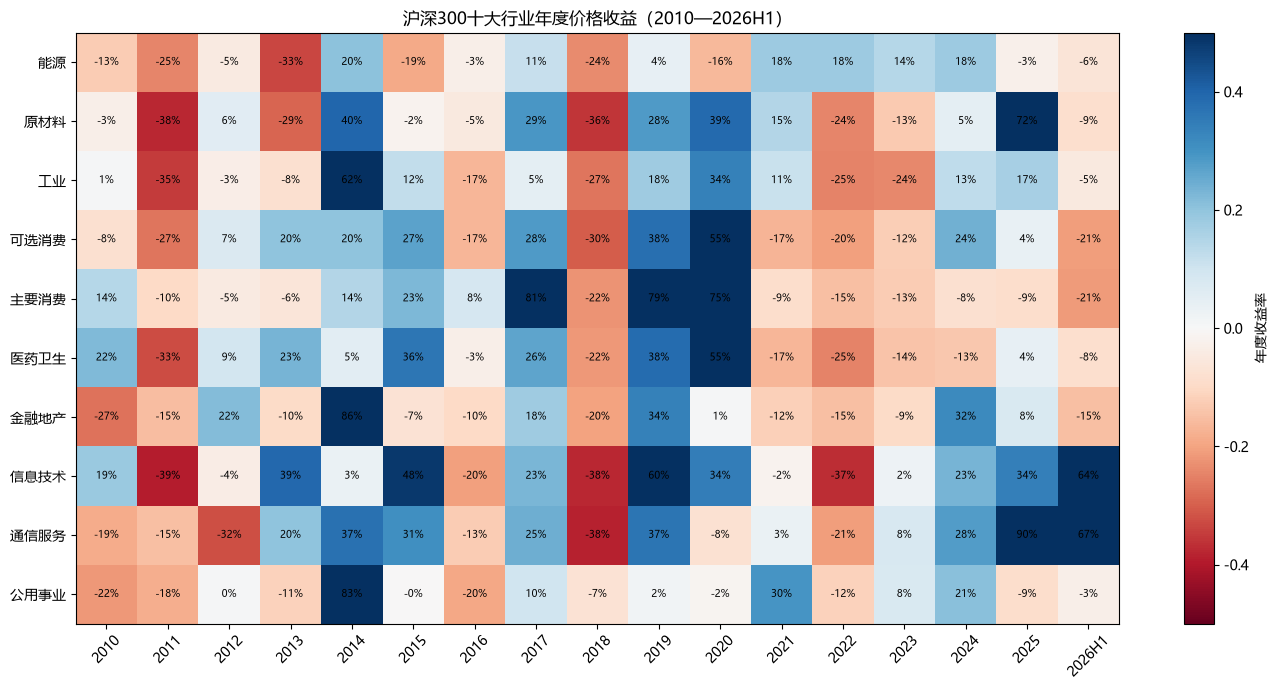

In [5]:
sector_returns = monthly_returns[SECTOR_NAMES]
annual_returns = sector_returns.groupby(sector_returns.index.year).apply(
    lambda frame: (1 + frame).prod() - 1
)
annual_returns.index = [
    f"{year}H1" if year == 2026 else str(year)
    for year in annual_returns.index
]
annual_returns.to_csv(
    DATA_DIR / "annual_sector_returns.csv",
    encoding="utf-8-sig",
)

annual_winners = pd.DataFrame(
    {
        "winner": annual_returns.idxmax(axis=1),
        "winner_return": annual_returns.max(axis=1),
        "loser": annual_returns.idxmin(axis=1),
        "loser_return": annual_returns.min(axis=1),
        "top_bottom_spread": (
            annual_returns.max(axis=1) - annual_returns.min(axis=1)
        ),
    }
)
display(annual_winners)

figure, axis = plt.subplots(figsize=(14, 7))
image = axis.imshow(
    annual_returns.T.values,
    cmap="RdBu",
    vmin=-0.50,
    vmax=0.50,
    aspect="auto",
)
axis.set_xticks(
    range(len(annual_returns.index)), annual_returns.index, rotation=45
)
axis.set_yticks(
    range(len(annual_returns.columns)), annual_returns.columns
)
axis.set_title("沪深300十大行业年度价格收益（2010—2026H1）")
for row_index in range(annual_returns.shape[1]):
    for column_index in range(annual_returns.shape[0]):
        value = annual_returns.iloc[column_index, row_index]
        axis.text(
            column_index,
            row_index,
            f"{value:.0%}",
            ha="center",
            va="center",
            fontsize=7,
        )
figure.colorbar(image, ax=axis, label="年度收益率")
figure.tight_layout()
figure.savefig(
    CHART_DIR / "annual_return_heatmap.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


,metric,value
0,月度冠军变更率,0.893401
1,相邻月Top3 Jaccard中位数,0.200000
2,Top3每月新进入数量均值,2.000000
3,月收益横截面标准差均值,0.046074
4,月最佳—最差收益差均值,0.146216
5,完整年度冠军行业种类数,7.000000


,leader_months,leader_share,longest_leader_streak
信息技术,31,0.156566,2
主要消费,31,0.156566,2
能源,24,0.121212,2
原材料,21,0.106061,2
通信服务,21,0.106061,4
公用事业,20,0.101010,1
医药卫生,18,0.090909,2
金融地产,14,0.070707,2
可选消费,13,0.065657,2
工业,5,0.025253,1


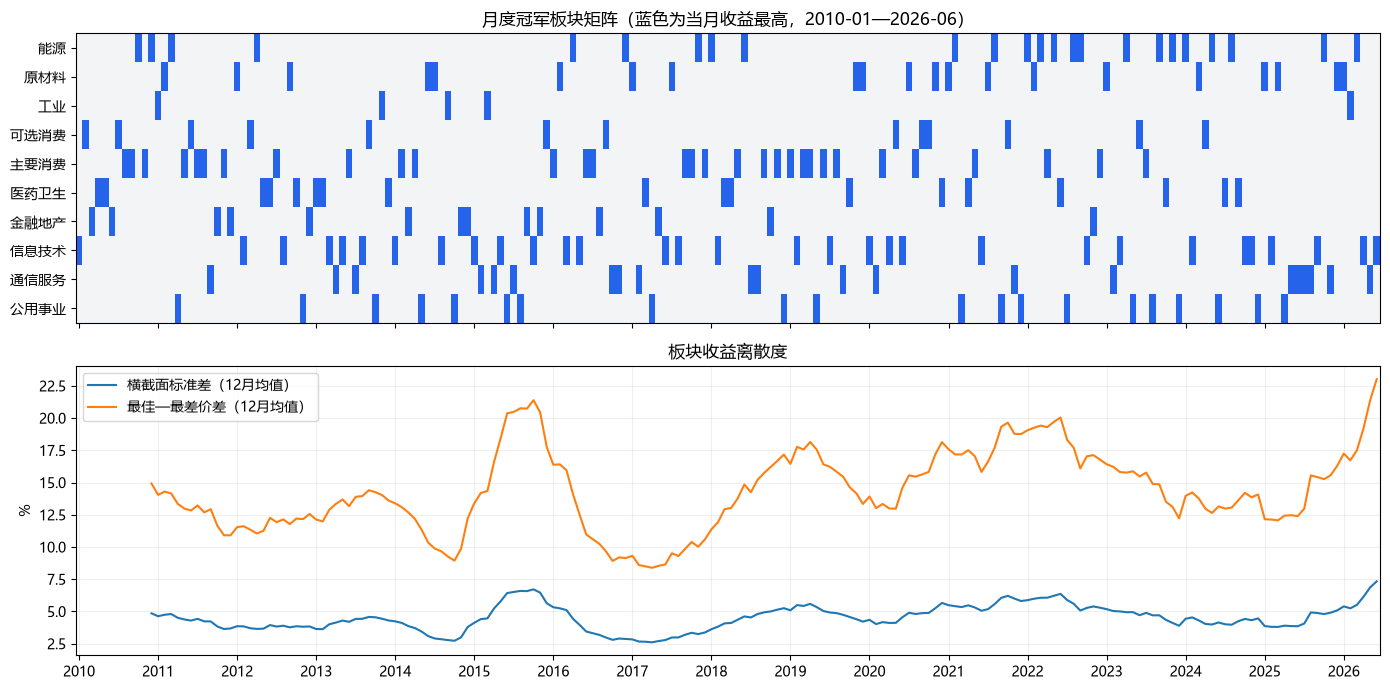

In [6]:
monthly_rank = sector_returns.rank(
    axis=1, ascending=False, method="first"
)
monthly_leader = monthly_rank.idxmin(axis=1)
top3_sets = monthly_rank.apply(
    lambda row: set(row.nsmallest(3).index), axis=1
)
leader_change = monthly_leader.ne(monthly_leader.shift(1))
leader_change.iloc[0] = False
leader_change_ratio = leader_change.iloc[1:].mean()
top3_jaccard = pd.Series(
    [
        np.nan
        if index == 0
        else len(top3_sets.iloc[index] & top3_sets.iloc[index - 1])
        / len(top3_sets.iloc[index] | top3_sets.iloc[index - 1])
        for index in range(len(top3_sets))
    ],
    index=top3_sets.index,
    name="top3_jaccard",
)
top3_new_entries = pd.Series(
    [
        np.nan
        if index == 0
        else len(top3_sets.iloc[index] - top3_sets.iloc[index - 1])
        for index in range(len(top3_sets))
    ],
    index=top3_sets.index,
    name="top3_new_entries",
)

def longest_streak(values: pd.Series, target: str) -> int:
    best = current = 0
    for value in values:
        if value == target:
            current += 1
            best = max(best, current)
        else:
            current = 0
    return best

leadership_summary = pd.DataFrame(
    {
        "leader_months": monthly_leader.value_counts(),
        "leader_share": monthly_leader.value_counts(normalize=True),
        "longest_leader_streak": [
            longest_streak(monthly_leader, sector)
            for sector in monthly_leader.value_counts().index
        ],
    }
).sort_values("leader_months", ascending=False)

dispersion = pd.DataFrame(
    {
        "cross_section_std": sector_returns.std(axis=1, ddof=1),
        "top_bottom_spread": (
            sector_returns.max(axis=1) - sector_returns.min(axis=1)
        ),
    }
)
rotation_summary = pd.DataFrame(
    [
        ("月度冠军变更率", leader_change_ratio),
        ("相邻月Top3 Jaccard中位数", top3_jaccard.median()),
        ("Top3每月新进入数量均值", top3_new_entries.mean()),
        ("月收益横截面标准差均值", dispersion["cross_section_std"].mean()),
        ("月最佳—最差收益差均值", dispersion["top_bottom_spread"].mean()),
        ("完整年度冠军行业种类数", annual_winners.iloc[:-1]["winner"].nunique()),
    ],
    columns=["metric", "value"],
)
display(rotation_summary)
display(leadership_summary)

leader_matrix = np.vstack(
    [
        monthly_leader.eq(sector).astype(int).to_numpy()
        for sector in SECTOR_NAMES
    ]
)
figure, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].imshow(
    leader_matrix,
    aspect="auto",
    cmap=ListedColormap(["#F3F4F6", "#2563EB"]),
    interpolation="nearest",
    vmin=0,
    vmax=1,
)
axes[0].set_yticks(range(len(SECTOR_NAMES)), SECTOR_NAMES)
axes[0].set_title("月度冠军板块矩阵（蓝色为当月收益最高，2010-01—2026-06）")
tick_positions = np.arange(0, len(monthly_leader), 12)
axes[0].set_xticks(
    tick_positions,
    [str(monthly_leader.index[position].year) for position in tick_positions],
)

x_values = np.arange(len(dispersion))
axes[1].plot(
    x_values,
    dispersion["cross_section_std"].rolling(12).mean() * 100,
    label="横截面标准差（12月均值）",
)
axes[1].plot(
    x_values,
    dispersion["top_bottom_spread"].rolling(12).mean() * 100,
    label="最佳—最差价差（12月均值）",
)
axes[1].set_ylabel("%")
axes[1].set_title("板块收益离散度")
axes[1].grid(alpha=0.2)
axes[1].legend()
figure.tight_layout()
figure.savefig(
    CHART_DIR / "leadership_and_dispersion.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


### 2. 领先地位能否延续

Rank IC 是当期信号横截面排名与下一月收益排名的相关。正值表示动量，负值表示反转。
`L1` 使用当月收益，`L3/L6/L12` 使用过去3/6/12个月累计收益。


,lookback_months,observations,mean_rank_ic,median_rank_ic,positive_ratio,t_stat_naive,top3_next_month_spread
0,1,197,0.019,0.030,52.8%,0.68,0.38%
1,3,195,0.033,0.055,53.3%,1.11,0.67%
2,6,192,0.040,0.067,54.2%,1.25,0.41%
3,12,186,0.071,0.097,57.0%,2.28,0.88%


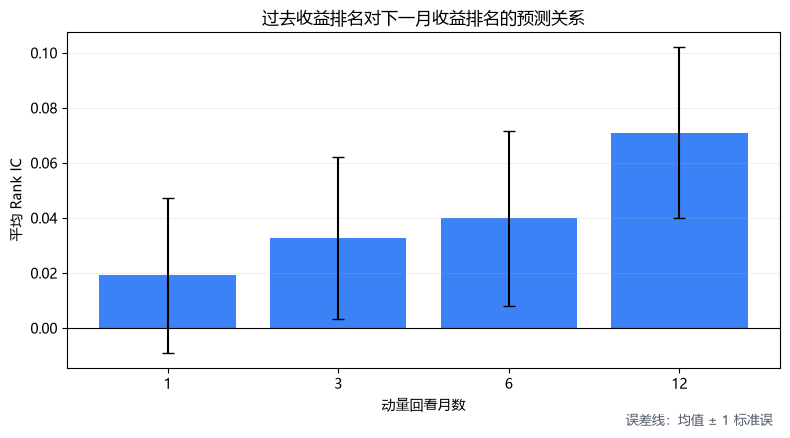

In [7]:
def cross_section_rank_ic(
    signal_frame: pd.DataFrame, future_return_frame: pd.DataFrame
) -> pd.Series:
    values = {}
    for month in signal_frame.index.intersection(future_return_frame.index):
        pair = pd.concat(
            [
                signal_frame.loc[month].rename("signal"),
                future_return_frame.loc[month].rename("future"),
            ],
            axis=1,
        ).dropna()
        if len(pair) < 5:
            values[month] = np.nan
            continue
        values[month] = pair["signal"].rank().corr(
            pair["future"].rank(), method="pearson"
        )
    return pd.Series(values).dropna()


future_returns = sector_returns.shift(-1)
ic_series = {}
spread_series = {}
for lookback in [1, 3, 6, 12]:
    signal = (
        sector_returns
        if lookback == 1
        else monthly_close[SECTOR_NAMES].pct_change(
            lookback, fill_method=None
        ).loc[MONTHLY_START:MONTHLY_END]
    )
    ic = cross_section_rank_ic(signal, future_returns)
    ic_series[lookback] = ic
    spreads = {}
    for month in signal.index.intersection(future_returns.index):
        pair = pd.concat(
            [
                signal.loc[month].rename("signal"),
                future_returns.loc[month].rename("future"),
            ],
            axis=1,
        ).dropna()
        if len(pair) != len(SECTOR_NAMES):
            continue
        top3 = pair.nlargest(3, "signal")
        rest = pair.drop(index=top3.index)
        spreads[month] = top3["future"].mean() - rest["future"].mean()
    spread_series[lookback] = pd.Series(spreads)

ic_summary = pd.DataFrame(
    [
        {
            "lookback_months": lookback,
            "observations": len(values),
            "mean_rank_ic": values.mean(),
            "median_rank_ic": values.median(),
            "positive_ratio": values.gt(0).mean(),
            "t_stat_naive": (
                values.mean() / (values.std(ddof=1) / math.sqrt(len(values)))
            ),
            "top3_next_month_spread": spread_series[lookback].mean(),
        }
        for lookback, values in ic_series.items()
    ]
)
ic_summary.to_csv(
    DATA_DIR / "rank_ic_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
display(ic_summary.style.format({
    "mean_rank_ic": "{:.3f}",
    "median_rank_ic": "{:.3f}",
    "positive_ratio": "{:.1%}",
    "t_stat_naive": "{:.2f}",
    "top3_next_month_spread": "{:.2%}",
}))

figure, axis = plt.subplots(figsize=(8, 4.5))
standard_errors = [
    ic_series[lookback].std(ddof=1) / math.sqrt(len(ic_series[lookback]))
    for lookback in ic_summary["lookback_months"]
]
axis.bar(
    ic_summary["lookback_months"].astype(str),
    ic_summary["mean_rank_ic"],
    yerr=standard_errors,
    capsize=4,
    color="#3B82F6",
)
axis.axhline(0, color="black", lw=0.8)
axis.set_xlabel("动量回看月数")
axis.set_ylabel("平均 Rank IC")
axis.set_title("过去收益排名对下一月收益排名的预测关系")
axis.grid(axis="y", alpha=0.2)
axis.text(
    0.99,
    -0.17,
    "误差线：均值 ± 1 标准误",
    transform=axis.transAxes,
    ha="right",
    fontsize=9,
    color="#4B5563",
)
figure.tight_layout()
figure.savefig(
    CHART_DIR / "rank_ic.png", dpi=160, bbox_inches="tight"
)
plt.show()


### 3. 无前视轮动规则与成本

每个月末只使用当时已有的过去收益，下一月持有Top 3或Top 5。参考规则在看结果前固定为
`12个月动量 Top 3，单边成本20 bp`。所有参数统一从2011-01开始比较。


In [8]:
def build_strategy(lookback: int, top_k: int) -> pd.DataFrame:
    signal = monthly_close[SECTOR_NAMES].pct_change(
        lookback, fill_method=None
    ).loc[MONTHLY_START:MONTHLY_END]
    target = pd.DataFrame(
        0.0, index=signal.index, columns=SECTOR_NAMES
    )
    for month, row in signal.iterrows():
        valid = row.dropna()
        if len(valid) == len(SECTOR_NAMES):
            selected = valid.nlargest(top_k).index
            target.loc[month, selected] = 1.0 / top_k

    held = target.shift(1)
    gross = (held * sector_returns).sum(axis=1, min_count=1)
    gross = gross.where(held.sum(axis=1).gt(0))
    turnover = 0.5 * held.diff().abs().sum(axis=1)
    first_invested = held.sum(axis=1).gt(0) & held.shift(1).sum(axis=1).eq(0)
    turnover.loc[first_invested] = 1.0
    return pd.DataFrame({"gross_return": gross, "turnover": turnover})


def performance_metrics(
    returns: pd.Series, turnover: pd.Series | None = None
) -> dict:
    clean = returns.dropna()
    wealth = (1 + clean).cumprod()
    years = len(clean) / 12
    cagr = wealth.iloc[-1] ** (1 / years) - 1
    volatility = clean.std(ddof=1) * math.sqrt(12)
    sharpe = (
        clean.mean() / clean.std(ddof=1) * math.sqrt(12)
        if clean.std(ddof=1) > 0
        else np.nan
    )
    max_drawdown = (wealth / wealth.cummax() - 1).min()
    aligned_turnover = (
        turnover.reindex(clean.index).dropna()
        if turnover is not None
        else pd.Series(dtype=float)
    )
    return {
        "months": len(clean),
        "cagr": cagr,
        "annual_volatility": volatility,
        "sharpe_rf0": sharpe,
        "max_drawdown": max_drawdown,
        "positive_month_ratio": clean.gt(0).mean(),
        "annual_turnover": (
            aligned_turnover.mean() * 12
            if not aligned_turnover.empty
            else 0.0
        ),
        "ending_wealth": wealth.iloc[-1],
    }


evaluation_index = monthly_returns.loc[
    EVALUATION_START:MONTHLY_END
].index
equal_weight_return = sector_returns.mean(axis=1).reindex(evaluation_index)
benchmark_return = monthly_returns[BENCHMARK_NAME].reindex(evaluation_index)

strategy_cache = {}
cost_levels_bps = [0, 10, 20, 50]
cost_rows = []
performance_rows = []

for lookback in [3, 6, 12]:
    for top_k in [3, 5]:
        strategy_name = f"M{lookback}_Top{top_k}"
        strategy = build_strategy(lookback, top_k).reindex(evaluation_index)
        strategy_cache[strategy_name] = strategy
        for cost_bps in cost_levels_bps:
            net_return = (
                strategy["gross_return"]
                - strategy["turnover"] * cost_bps / 10_000
            )
            metrics = performance_metrics(
                net_return, strategy["turnover"]
            )
            cost_rows.append(
                {
                    "strategy": strategy_name,
                    "cost_bps": cost_bps,
                    **metrics,
                }
            )
        net20 = (
            strategy["gross_return"]
            - strategy["turnover"] * 20 / 10_000
        )
        performance_rows.append(
            {
                "strategy": strategy_name + "_net20",
                **performance_metrics(net20, strategy["turnover"]),
            }
        )

performance_rows.extend(
    [
        {
            "strategy": "十大行业等权",
            **performance_metrics(equal_weight_return),
        },
        {
            "strategy": BENCHMARK_NAME,
            **performance_metrics(benchmark_return),
        },
    ]
)
performance_table = pd.DataFrame(performance_rows).sort_values(
    "cagr", ascending=False
)
cost_sensitivity = pd.DataFrame(cost_rows)
performance_table.to_csv(
    DATA_DIR / "strategy_performance.csv",
    index=False,
    encoding="utf-8-sig",
)
cost_sensitivity.to_csv(
    DATA_DIR / "cost_sensitivity.csv",
    index=False,
    encoding="utf-8-sig",
)
display(performance_table.style.format({
    "cagr": "{:.2%}",
    "annual_volatility": "{:.2%}",
    "sharpe_rf0": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "positive_month_ratio": "{:.1%}",
    "annual_turnover": "{:.2f}",
    "ending_wealth": "{:.2f}",
}))
display(
    cost_sensitivity.pivot(
        index="strategy", columns="cost_bps", values="cagr"
    ).style.format("{:.2%}")
)


,strategy,months,cagr,annual_volatility,sharpe_rf0,max_drawdown,positive_month_ratio,annual_turnover,ending_wealth
4,M12_Top3_net20,186,10.41%,23.98%,0.53,-46.66%,57.5%,2.04,4.64
5,M12_Top5_net20,186,8.32%,21.36%,0.48,-46.96%,55.4%,1.52,3.45
0,M3_Top3_net20,186,7.57%,23.59%,0.42,-43.05%,55.4%,4.41,3.10
2,M6_Top3_net20,186,5.96%,24.16%,0.36,-49.81%,55.4%,3.35,2.45
1,M3_Top5_net20,186,5.72%,21.81%,0.36,-41.40%,52.2%,3.20,2.37
3,M6_Top5_net20,186,5.65%,21.01%,0.37,-43.19%,53.8%,2.31,2.34
6,十大行业等权,186,3.92%,19.77%,0.29,-42.16%,55.9%,0.00,1.81
7,沪深300,186,3.04%,21.18%,0.25,-40.56%,52.2%,0.00,1.59


cost_bps,0,10,20,50
strategy,,,,
M12_Top3,10.86%,10.64%,10.41%,9.75%
M12_Top5,8.65%,8.48%,8.32%,7.83%
M3_Top3,8.52%,8.05%,7.57%,6.17%
M3_Top5,6.40%,6.06%,5.72%,4.72%
M6_Top3,6.67%,6.32%,5.96%,4.90%
M6_Top5,6.14%,5.90%,5.65%,4.93%


series,12月动量Top3（净20bp）,十大行业等权,沪深300
period,,,
2011-2014,5.86%,-0.11%,3.09%
2015-2019,3.53%,5.16%,3.00%
2020-2026H1,19.07%,5.51%,3.05%


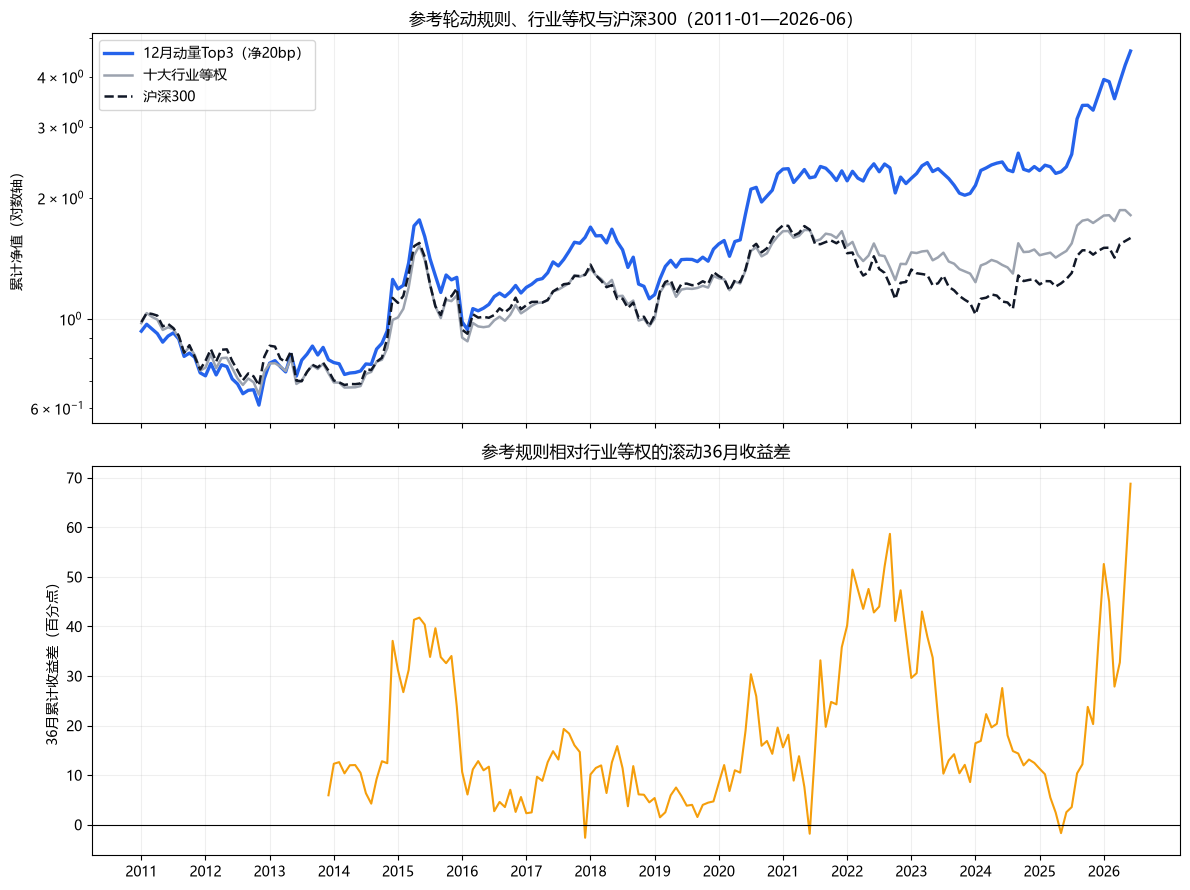

In [9]:
reference_name = "M12_Top3"
reference = strategy_cache[reference_name]
reference_net20 = (
    reference["gross_return"] - reference["turnover"] * 20 / 10_000
).reindex(evaluation_index)

comparison_returns = pd.DataFrame(
    {
        "12月动量Top3（净20bp）": reference_net20,
        "十大行业等权": equal_weight_return,
        BENCHMARK_NAME: benchmark_return,
    }
).dropna()
wealth = (1 + comparison_returns).cumprod()

subperiods = {
    "2011-2014": (pd.Period("2011-01", "M"), pd.Period("2014-12", "M")),
    "2015-2019": (pd.Period("2015-01", "M"), pd.Period("2019-12", "M")),
    "2020-2026H1": (pd.Period("2020-01", "M"), MONTHLY_END),
}
subperiod_rows = []
for period_name, (start_month, end_month) in subperiods.items():
    for series_name in comparison_returns.columns:
        sub_returns = comparison_returns.loc[
            start_month:end_month, series_name
        ]
        subperiod_rows.append(
            {
                "period": period_name,
                "series": series_name,
                **performance_metrics(sub_returns),
            }
        )
subperiod_table = pd.DataFrame(subperiod_rows)
subperiod_table.to_csv(
    DATA_DIR / "subperiod_performance.csv",
    index=False,
    encoding="utf-8-sig",
)
display(
    subperiod_table.pivot(
        index="period", columns="series", values="cagr"
    ).style.format("{:.2%}")
)

figure, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
x_values = np.arange(len(wealth))
line_styles = {
    "12月动量Top3（净20bp）": {
        "color": "#2563EB", "linewidth": 2.4, "linestyle": "-"
    },
    "十大行业等权": {
        "color": "#9CA3AF", "linewidth": 1.8, "linestyle": "-"
    },
    BENCHMARK_NAME: {
        "color": "#111827", "linewidth": 1.8, "linestyle": "--"
    },
}
for series_name in wealth.columns:
    axes[0].plot(
        x_values,
        wealth[series_name],
        label=series_name,
        **line_styles[series_name],
    )
axes[0].set_yscale("log")
axes[0].set_ylabel("累计净值（对数轴）")
axes[0].set_title("参考轮动规则、行业等权与沪深300（2011-01—2026-06）")
axes[0].grid(alpha=0.2)
axes[0].legend()

excess_36m = (
    (1 + comparison_returns["12月动量Top3（净20bp）"])
    .rolling(36)
    .apply(np.prod, raw=True)
    - (1 + comparison_returns["十大行业等权"])
    .rolling(36)
    .apply(np.prod, raw=True)
)
axes[1].plot(x_values, excess_36m * 100, color="#F59E0B")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("36月累计收益差（百分点）")
axes[1].set_title("参考规则相对行业等权的滚动36月收益差")
axes[1].grid(alpha=0.2)
tick_positions = np.arange(0, len(wealth), 12)
axes[1].set_xticks(
    tick_positions,
    [str(wealth.index[position].year) for position in tick_positions],
)
figure.tight_layout()
figure.savefig(
    CHART_DIR / "strategy_wealth_and_rolling_excess.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


## Takeaways

1. **存在轮动空间**：完整年度冠军覆盖7个行业，月度冠军变更率89.34%，
   月度最佳—最差收益差均值14.62个百分点。
2. **短期持续性弱、12个月持续性较强**：只有12个月Rank IC达到0.071，
   其余回看期接近零；不能把“冠军更替”误读为短期可预测。
3. **参数方向大体一致**：六个动量参数组合扣20 bp后的CAGR均高于行业等权和
   沪深300，但12个月参数明显最好，仍存在参数选择和多重检验风险。
4. **成本不是主要反驳，回撤与阶段性才是**：参考规则在50 bp成本下CAGR仍为
   9.75%，但最大回撤-46.66%，且2015—2019年落后行业等权。
5. **可实施性尚未闭环**：行业价格指数不含分红，早期ETF产品并不完备，
   本结果不能直接等同于真实ETF组合收益。

下方运行清单保存关键数字，供总体研究结论和独立复算引用。


In [10]:
reference_metrics = performance_metrics(
    reference_net20, reference["turnover"]
)
equal_weight_metrics = performance_metrics(equal_weight_return)
benchmark_metrics = performance_metrics(benchmark_return)
best_net20 = performance_table.loc[
    performance_table["strategy"].str.endswith("_net20")
].iloc[0]

manifest = {
    "schema_version": "1.0",
    "run_time": pd.Timestamp.now(tz="Asia/Shanghai").isoformat(),
    "daily_data_end": DAILY_END.date().isoformat(),
    "monthly_window": {
        "start": str(MONTHLY_START),
        "end": str(MONTHLY_END),
        "months": int(len(monthly_returns)),
    },
    "evaluation_window": {
        "start": str(EVALUATION_START),
        "end": str(MONTHLY_END),
        "months": int(len(evaluation_index)),
    },
    "universe": {
        "classification": "中证行业分类",
        "parent_universe": "沪深300",
        "sector_count": len(SECTOR_NAMES),
        "sectors": SECTOR_NAMES,
    },
    "data_quality": {
        "source": "腾讯财经",
        "validation_source": "新浪财经",
        "max_cross_source_relative_diff": float(
            source_quality["max_relative_diff"].max()
        ),
        "all_series_cover_2010": bool(
            primary_quality["start_date"]
            .le(pd.Timestamp("2010-01-04"))
            .all()
        ),
    },
    "rotation": {
        "monthly_leader_change_ratio": float(leader_change_ratio),
        "top3_jaccard_median": float(top3_jaccard.median()),
        "top3_new_entries_mean": float(top3_new_entries.mean()),
        "monthly_dispersion_mean": float(
            dispersion["cross_section_std"].mean()
        ),
        "monthly_top_bottom_spread_mean": float(
            dispersion["top_bottom_spread"].mean()
        ),
        "distinct_full_year_winners": int(
            annual_winners.iloc[:-1]["winner"].nunique()
        ),
    },
    "rank_ic": ic_summary.to_dict("records"),
    "reference_strategy": {
        "name": "12个月动量Top3，单边成本20bp",
        **{key: float(value) for key, value in reference_metrics.items()},
    },
    "equal_weight": {
        **{key: float(value) for key, value in equal_weight_metrics.items()},
    },
    "benchmark": {
        "name": BENCHMARK_NAME,
        **{key: float(value) for key, value in benchmark_metrics.items()},
    },
    "best_net20_strategy": {
        key: (
            float(value)
            if isinstance(value, (float, np.floating, int, np.integer))
            else value
        )
        for key, value in best_net20.to_dict().items()
    },
    "subperiod_cagr": subperiod_table[
        ["period", "series", "cagr"]
    ].to_dict("records"),
    "required_caveats": [
        "指数为价格指数，不含股息再投资",
        "历史上行业指数不一定有可交易ETF",
        "未计冲击成本、申赎限制和税费",
        "参数矩阵仍存在多重检验和数据挖掘风险",
        "相关和动量证据不代表宏观因果",
    ],
}
(DATA_DIR / "run_manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

assert len(ic_summary) == 4
assert len(performance_table) == 8
assert len(cost_sensitivity) == 24
assert len(subperiod_table) == 9
assert comparison_returns.notna().all().all()
assert math.isclose(
    reference_metrics["ending_wealth"],
    (1 + reference_net20.dropna()).prod(),
    rel_tol=1e-12,
)
print("轮动计算、成本敏感性、子区间与运行清单校验通过")
print("数据目录:", DATA_DIR.relative_to(LAB_DIR.parents[1]))


轮动计算、成本敏感性、子区间与运行清单校验通过
数据目录: labs\03_板块周期轮动研究\data


### 解释边界

- 轮动空间不等于轮动可预测；
- 事后最佳参数不构成可复现优势，必须优先看预设参考规则和参数方向一致性；
- 价格指数策略不能直接替代ETF回测，尤其是2010年代早期的产品可得性；
- 20 bp只是线性成本假设，真实冲击成本会随规模和流动性变化；
- 子区间差异若很大，应将结果判为“阶段有效”，而不是稳定规律；
- 本实验不构成投资建议。
